# Model Comparison for Student Academic Performance Prediction

**Fairness-Aware & Explainable Machine Learning**

This notebook trains and rigorously compares **six supervised classifiers** that
predict whether a student **passes** (final grade `G3 >= 10`) or **fails**, using the
merged *Mathematics* (`mat2.csv`) and *Portuguese* (`por2.csv`) UCI student performance
datasets already explored in `student_eda.ipynb`.

### Models compared
| Model | Family | Notes |
|-------|--------|-------|
| Logistic Regression | Linear | Baseline classifier |
| Lasso (L1) Logistic Regression | Linear (sparse) | L1 penalty -> automatic feature selection |
| XGBoost | Gradient-boosted trees | Regularised boosting of trees |
| AdaBoost | Adaptive boosting | Sequence of weak decision stumps |
| CatBoost | Gradient-boosted trees | Handles categorical structures well |
| Random Forest | Bagged trees | Ensemble of decorrelated trees |

### Evaluation protocol
Every model is scored with a **25-time repeated, 5-fold stratified cross-validation**
(25 hold-out folds per model) on the standard classification metrics **Accuracy,
Precision, Recall, F1-score and ROC-AUC**. A single stratified hold-out set is then used
for ROC / Precision-Recall curves, confusion matrices, calibration curves and
feature-importance diagnostics.


## 1. Setup
Import the required scientific libraries and apply a **publication-ready visual
style** (bold axis labels and titles, clear tick labels, light grid lines) so that every
figure is self-explanatory.


In [1]:
import warnings
warnings.filterwarnings('ignore')   

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix, average_precision_score, brier_score_loss)
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

%matplotlib inline

In [2]:

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'font.weight': 'bold',
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'legend.frameon': True,
    'figure.titlesize': 16,
    'figure.titleweight': 'bold',
    'axes.grid': True,
    'grid.alpha': 0.3,
})


MODELS_ORDER = ['Logistic Regression', 'Lasso (L1) Logistic', 'XGBoost',
                'AdaBoost', 'CatBoost', 'Random Forest']
MODEL_COLORS = {
    'Logistic Regression': '#4C72B0',
    'Lasso (L1) Logistic': '#DD8452',
    'XGBoost':             '#55A868',
    'AdaBoost':            '#C44E52',
    'CatBoost':            '#8172B3',
    'Random Forest':       '#937860',
}

## 2. Load and merge the datasets
Both CSV files share the same 34 columns. We (1) drop the auto-index column `Unnamed: 0`
(it carries no information, as shown in the EDA) and (2) concatenate the two subjects into
one modelling table to increase the sample size. The EDA already confirmed there is
**no missing data** and that `G3` (0-20) is the target.


In [3]:
mat_df = pd.read_csv('Student Performance Prediction Dataset/mat2.csv')
por_df = pd.read_csv('Student Performance Prediction Dataset/por2.csv')

for d in (mat_df, por_df):
    d.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

df = pd.concat([mat_df, por_df], ignore_index=True)
print('Mathematics  :', mat_df.shape)
print('Portuguese   :', por_df.shape)
print('Merged table :', df.shape)
print('Pass rate    : {:.1f}%'.format((df['G3'] >= 10).mean() * 100))

Mathematics  : (395, 33)
Portuguese   : (649, 33)
Merged table : (1044, 33)
Pass rate    : 78.0%


## 3. Task definition and pre-processing
We cast the problem as **binary classification** so the requested Logistic Regression
plays its natural role: `y = 1` when `G3 >= 10` (pass), otherwise `y = 0`. Following the
EDA's fairness angle we **exclude the prior grades `G1` / `G2`** so the comparison
reflects demographic and behavioural signal rather than near-perfect prior-grade info.

Categorical features are **one-hot encoded** and numeric features are **standardised**,
all inside a scikit-learn `ColumnTransformer`, so every model receives the same input.
Column groups are detected from the data types, so there is no hard-coded feature list.


In [4]:

obj_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ('G1', 'G2', 'G3')]

X = df[num_cols + obj_cols]
y = (df['G3'] >= 10).astype(int)

print('Numeric features :', len(num_cols), '->', num_cols)
print('Categorical feats:', len(obj_cols), '->', obj_cols)
print('N =', len(X), '| positives (pass) =', y.sum(), '| negatives =', int((y == 0).sum()))

ct = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), obj_cols),
])

Numeric features : 13 -> ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
Categorical feats: 17 -> ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
N = 1044 | positives (pass) = 814 | negatives = 230


## 4. Define the six models
Each model is wrapped in a `Pipeline` (`transform -> classifier`) that reuses the same
`ColumnTransformer`, guaranteeing fair, identical inputs. A fixed `random_state`
everywhere makes the comparison fully reproducible.


In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Lasso (L1) Logistic': LogisticRegression(penalty='l1', solver='liblinear',
                                              max_iter=2000, C=1.0, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, eval_metric='logloss',
                                         random_state=42),
    'AdaBoost':            AdaBoostClassifier(n_estimators=200, random_state=42),
    'CatBoost':            CatBoostClassifier(n_estimators=200, verbose=0,
                                              random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
}
pipelines = {name: Pipeline([('ct', ct), ('clf', clf)]) for name, clf in models.items()}
print('Ready to train:', ', '.join(models))
print()
for name, clf in models.items():
    print(f'{name:<22} params: {type(clf).__name__}')

Ready to train: Logistic Regression, Lasso (L1) Logistic, XGBoost, AdaBoost, CatBoost, Random Forest

Logistic Regression    params: LogisticRegression
Lasso (L1) Logistic    params: LogisticRegression
XGBoost                params: XGBClassifier
AdaBoost               params: AdaBoostClassifier
CatBoost               params: CatBoostClassifier
Random Forest          params: RandomForestClassifier


## 5. Robust repeated cross-validated evaluation
We run a **repeated stratified 5-fold cross-validation** (5 repetitions = 25 hold-out
folds per model, 150 fits in total). This yields a distribution of each metric per model,
which lets us show mean +/- spread instead of a single point estimate.


In [7]:
METRICS = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

records = []
for name, pipe in pipelines.items():
    for tr_idx, te_idx in rkf.split(X, y):
        Xtr, Xte = X.iloc[tr_idx], X.iloc[te_idx]
        ytr, yte = y.iloc[tr_idx], y.iloc[te_idx]
        pipe.fit(Xtr, ytr)
        proba = pipe.predict_proba(Xte)[:, 1]
        pred  = (proba >= 0.5).astype(int)
        records.append({'model': name,
                        'accuracy':  accuracy_score(yte, pred),
                        'precision': precision_score(yte, pred, zero_division=0),
                        'recall':    recall_score(yte, pred, zero_division=0),
                        'f1':        f1_score(yte, pred, zero_division=0),
                        'roc_auc':   roc_auc_score(yte, proba)})

cv = pd.DataFrame(records)
cv_mean = cv.groupby('model')[METRICS].mean().reindex(MODELS_ORDER)
cv_std  = cv.groupby('model')[METRICS].std().reindex(MODELS_ORDER)
print('Total CV fits:', len(cv), '(', len(MODELS_ORDER), 'models x 25 folds )')
print()
print(cv_mean.round(4))

Total CV fits: 150 ( 6 models x 25 folds )

                     accuracy  precision  recall      f1  roc_auc
model                                                            
Logistic Regression    0.7931     0.8169  0.9472  0.8771   0.7193
Lasso (L1) Logistic    0.7933     0.8146  0.9516  0.8777   0.7226
XGBoost                0.7638     0.8238  0.8867  0.8540   0.6982
AdaBoost               0.7931     0.8278  0.9278  0.8748   0.7226
CatBoost               0.7983     0.8254  0.9403  0.8790   0.7217
Random Forest          0.7732     0.8113  0.9243  0.8640   0.7077


## 6. Evaluation plots
All figures below compare the six models. The cross-validation figures (6.1-6.3) use the
repeated-CV distributions; the curve figures (6.4-6.8) use a single stratified hold-out.


### 6.1 Grouped bar chart of mean CV metrics (with spread)
The main comparison chart: each model has five grouped bars (Accuracy, Precision, Recall,
F1, ROC-AUC) with error bars = standard deviation over the 25 CV folds. Values are
annotated on every bar.


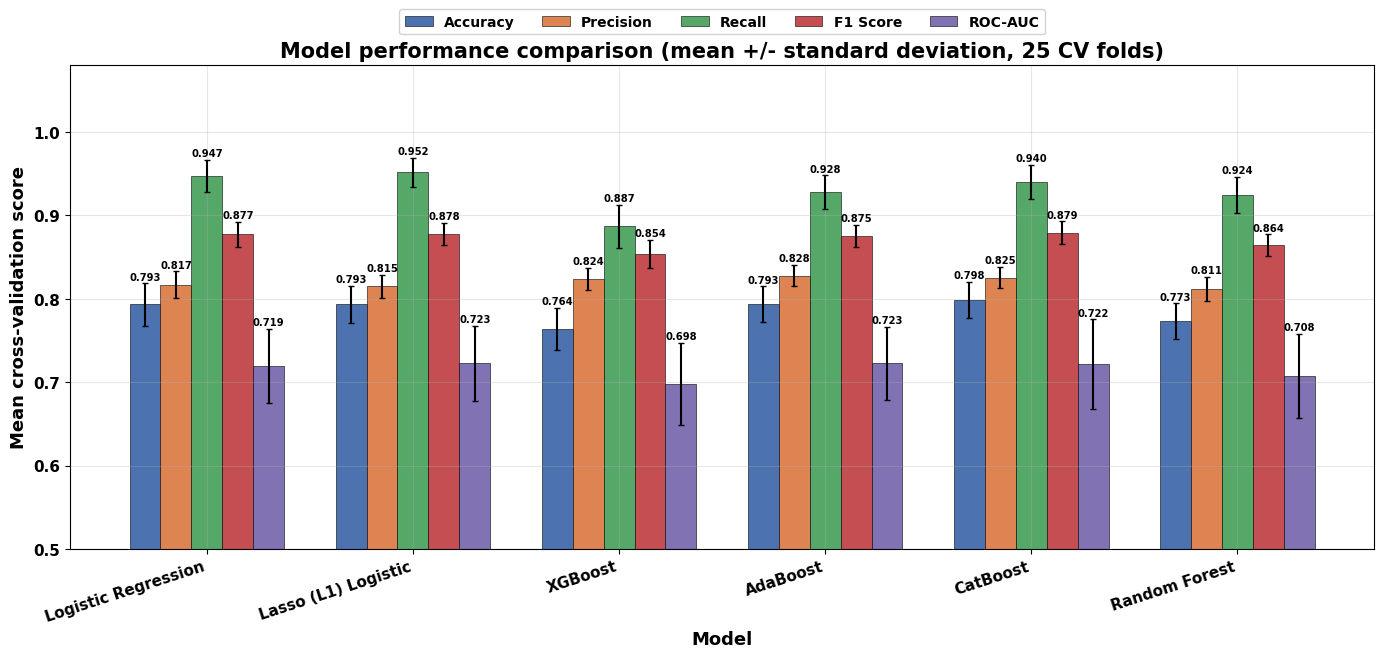

In [8]:
labels_ = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
metric_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
width, x = 0.15, np.arange(len(MODELS_ORDER))

fig, ax = plt.subplots(figsize=(14, 6.8))
for i, (m, lab, col) in enumerate(zip(METRICS, labels_, metric_colors)):
    bars = ax.bar(x + (i - 2) * width, cv_mean[m].values, width,
                  yerr=cv_std[m].values, label=lab, color=col,
                  capsize=2.0, edgecolor='black', linewidth=0.4)
    ax.bar_label(bars, fmt='%.3f', fontsize=7.2, padding=1)

ax.set_xticks(x)
ax.set_xticklabels(MODELS_ORDER, rotation=18, ha='right')
ax.set_ylim(0.5, 1.08)
ax.set_ylabel('Mean cross-validation score', fontsize=13, fontweight='bold')
ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_title('Model performance comparison (mean +/- standard deviation, 25 CV folds)',
             fontsize=15, fontweight='bold')
ax.legend(ncol=5, loc='upper center', bbox_to_anchor=(0.5, 1.13), framealpha=0.9)
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

### 6.2 Heatmap of mean CV metrics
A compact (model x metric) matrix of the mean CV score. Rows are ordered so the strongest
overall model is at the top.


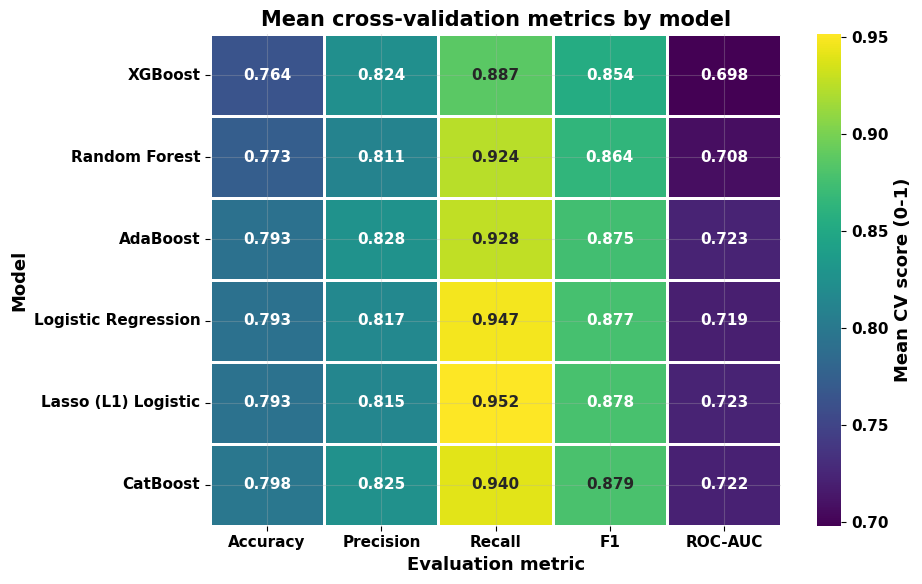

In [9]:
means_sorted = cv_mean.loc[cv_mean['f1'].sort_values().index]
fig, ax = plt.subplots(figsize=(9.5, 6.0))
sns.heatmap(means_sorted, annot=True, fmt='.3f', cmap='viridis', linewidths=0.8,
            cbar_kws={'label': 'Mean CV score (0-1)'}, annot_kws={'size': 11}, ax=ax)
ax.set_title('Mean cross-validation metrics by model', fontsize=15, fontweight='bold')
ax.set_xlabel('Evaluation metric', fontsize=13, fontweight='bold')
ax.set_ylabel('Model', fontsize=13, fontweight='bold')
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
                   fontsize=11, fontweight='bold')
fig.tight_layout()
plt.show()

### 6.3 F1-score distribution across CV folds
Box plots expose the fold-to-fold *variance* of each model, ordered by median F1.
Central tendency and stability are both visible here.


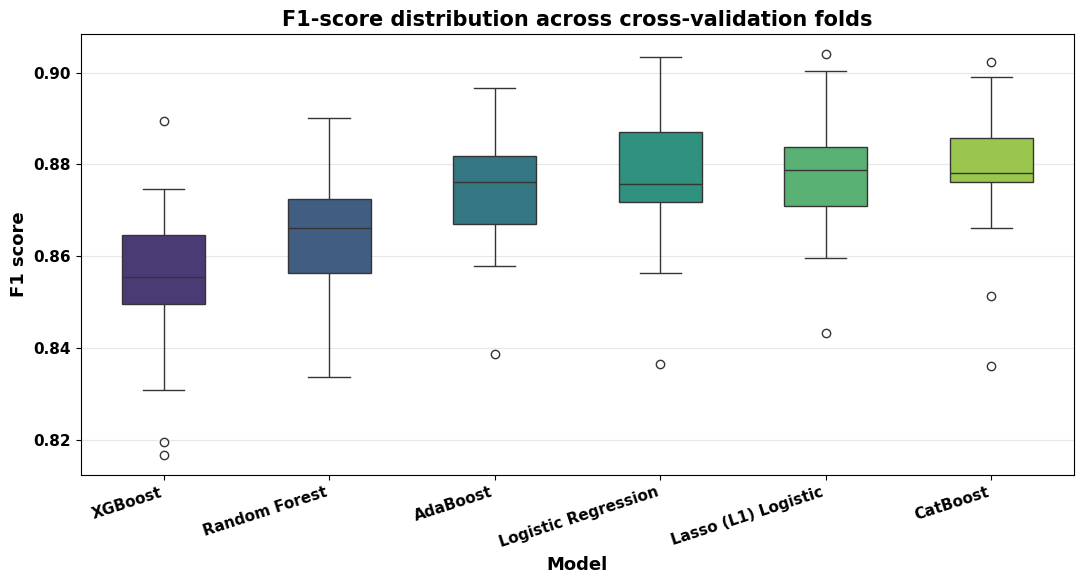

In [10]:
order_f1 = cv.groupby('model')['f1'].mean().sort_values().index
fig, ax = plt.subplots(figsize=(11, 6.0))
sns.boxplot(data=cv, x='model', y='f1', order=order_f1, palette='viridis',
            width=0.5, ax=ax)
ax.set_xticklabels(order_f1, rotation=18, ha='right')
ax.set_title('F1-score distribution across cross-validation folds',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('F1 score', fontsize=13, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

### 6.4 Stratified hold-out set for curve diagnostics
For the ROC / Precision-Recall curves, confusion matrices and calibration curves we train
each model once on a fresh 70/30 stratified split so that all models are evaluated on the
*same* unseen test set.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
print('Train:', X_train.shape[0], '| Test:', X_test.shape[0])

fit_proba, fit_pred = {}, {}
for name in MODELS_ORDER:
    pipe = Pipeline([('ct', ct), ('clf', models[name])])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    fit_proba[name] = proba
    fit_pred[name] = (proba >= 0.5).astype(int)
    print(f'{name:<22} hold-out accuracy = {accuracy_score(y_test, fit_pred[name]):.3f}')

Train: 730 | Test: 314
Logistic Regression    hold-out accuracy = 0.771
Lasso (L1) Logistic    hold-out accuracy = 0.771
XGBoost                hold-out accuracy = 0.777
AdaBoost               hold-out accuracy = 0.780
CatBoost               hold-out accuracy = 0.783
Random Forest          hold-out accuracy = 0.783


### 6.5 ROC curves (hold-out)
Receiver-Operating-Characteristic curves plot the True-Positive Rate against the
False-Positive Rate at every threshold. Higher, more left-leaning curves (larger AUC) mean
better separation between passers and failures.


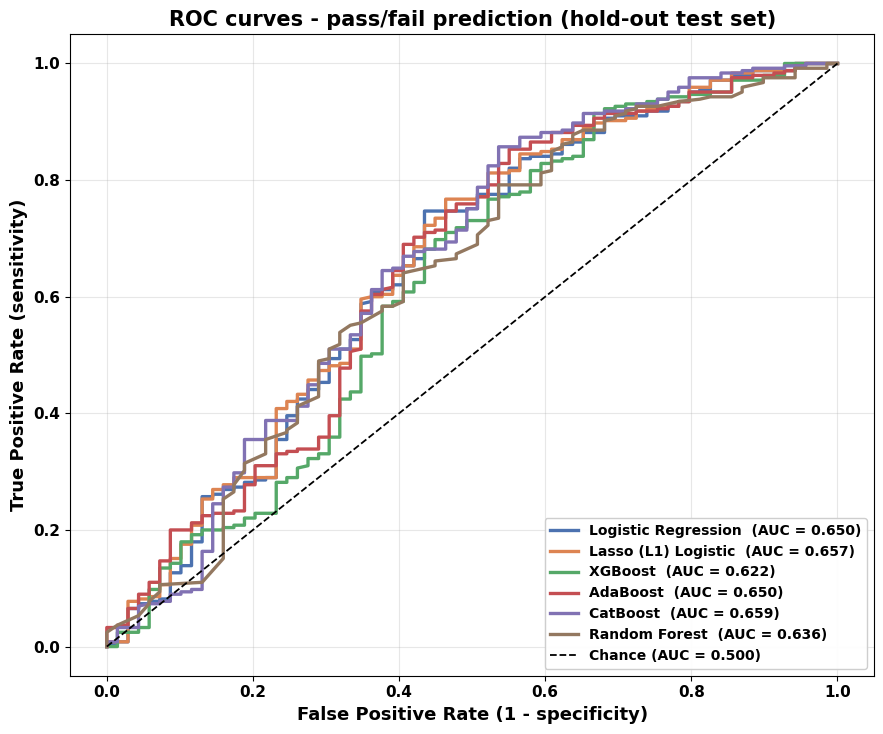

In [12]:
fig, ax = plt.subplots(figsize=(9, 7.5))
for name in MODELS_ORDER:
    fpr, tpr, _ = roc_curve(y_test, fit_proba[name])
    auc_v = roc_auc_score(y_test, fit_proba[name])
    ax.plot(fpr, tpr, lw=2.4, color=MODEL_COLORS[name],
            label=f'{name}  (AUC = {auc_v:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.3, label='Chance (AUC = 0.500)')
ax.set_xlabel('False Positive Rate (1 - specificity)', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate (sensitivity)', fontsize=13, fontweight='bold')
ax.set_title('ROC curves - pass/fail prediction (hold-out test set)',
             fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### 6.6 Precision-Recall curves (hold-out)
With an imbalanced target (~78% passers) the Precision-Recall curve is more informative
than the ROC curve. It shows how Precision trades off against Recall and is summarised by
the **Average Precision (AUPRC)**.


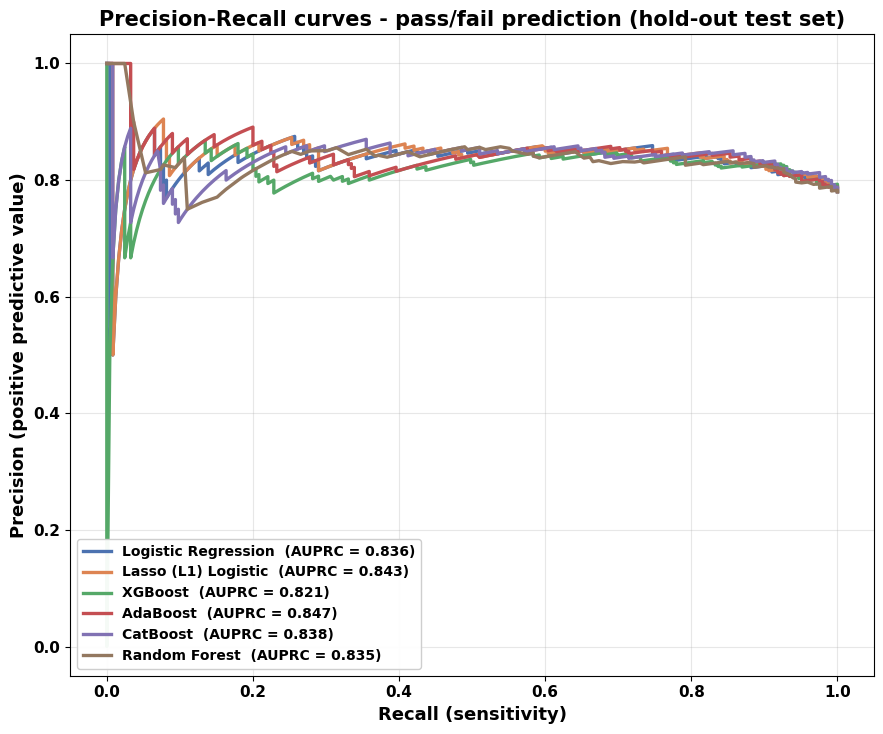

In [13]:
fig, ax = plt.subplots(figsize=(9, 7.5))
for name in MODELS_ORDER:
    prec, rec, _ = precision_recall_curve(y_test, fit_proba[name])
    auprc = average_precision_score(y_test, fit_proba[name])
    ax.plot(rec, prec, lw=2.4, color=MODEL_COLORS[name],
            label=f'{name}  (AUPRC = {auprc:.3f})')
ax.set_xlabel('Recall (sensitivity)', fontsize=13, fontweight='bold')
ax.set_ylabel('Precision (positive predictive value)', fontsize=13, fontweight='bold')
ax.set_title('Precision-Recall curves - pass/fail prediction (hold-out test set)',
             fontsize=15, fontweight='bold')
ax.legend(loc='lower left', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### 6.7 Confusion matrices (hold-out, threshold = 0.5)
Raw counts of true vs predicted labels reveal *where* each model errs - e.g. false
negatives (missed failures) vs false positives (false alarms).


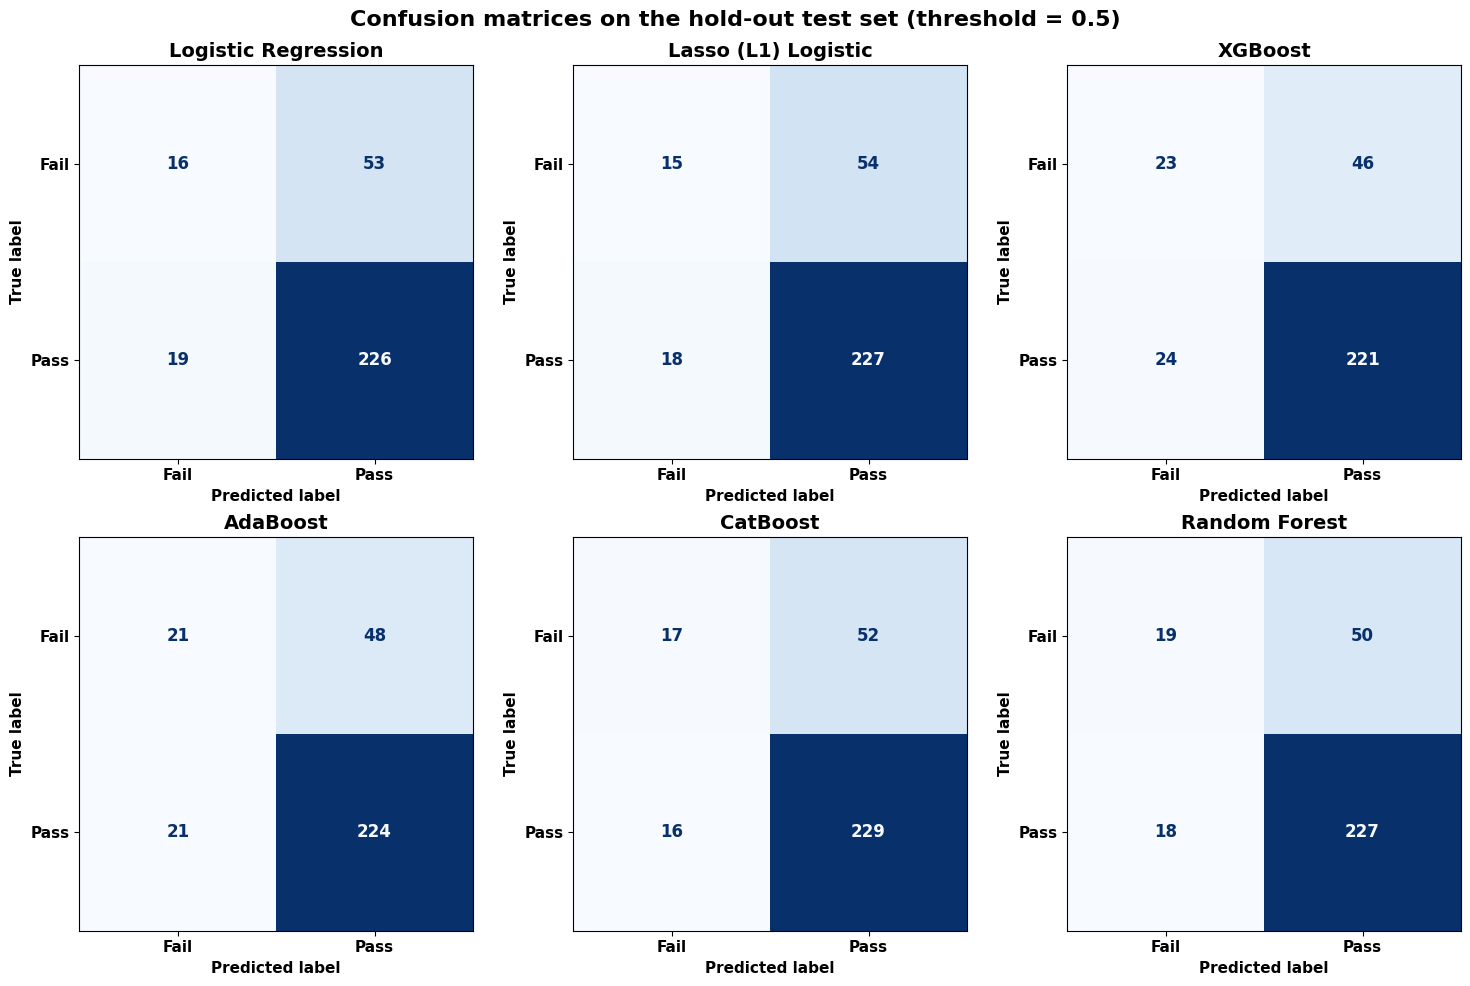

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, name in zip(axes.ravel(), MODELS_ORDER):
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, fit_pred[name]),
                                  display_labels=['Fail', 'Pass'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(name, fontweight='bold', fontsize=14)
    ax.set_xlabel('Predicted label', fontweight='bold', fontsize=11)
    ax.set_ylabel('True label', fontweight='bold', fontsize=11)
    ax.grid(False)
fig.suptitle('Confusion matrices on the hold-out test set (threshold = 0.5)',
             fontsize=16, fontweight='bold', y=0.98)
fig.tight_layout()
plt.show()

### 6.8 Calibration curves
Calibration measures how *honest* the predicted probabilities are: the closer a curve sits
to the diagonal, the better the predicted pass-probability matches the observed pass-rate.
The **Brier score** (lower = better) is printed for every model.


  Logistic Regression    Brier score = 0.1673
  Lasso (L1) Logistic    Brier score = 0.1648
  XGBoost                Brier score = 0.2004
  AdaBoost               Brier score = 0.2033
  CatBoost               Brier score = 0.1613
  Random Forest          Brier score = 0.1674


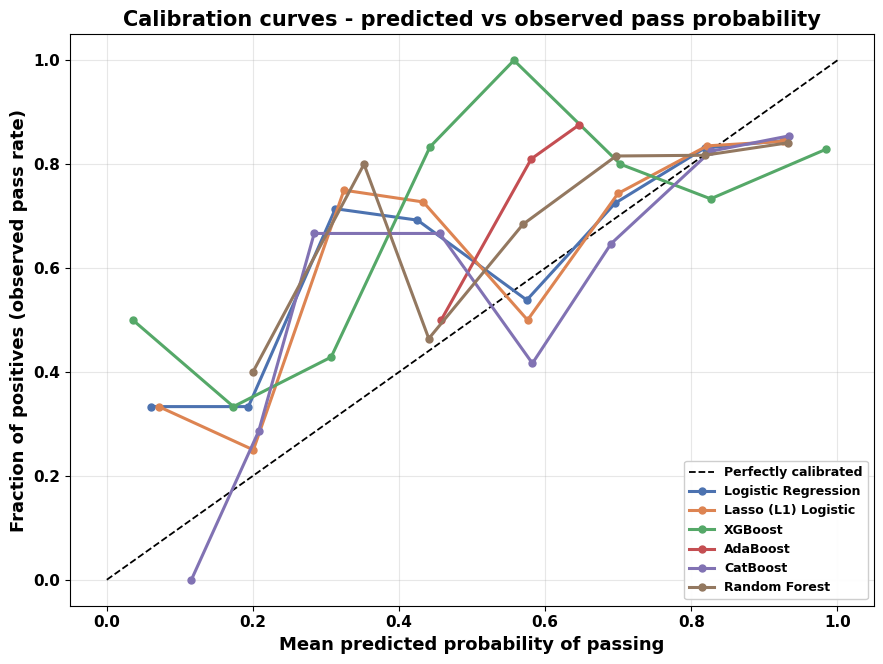

In [15]:
fig, ax = plt.subplots(figsize=(9, 6.8))
ax.plot([0, 1], [0, 1], 'k--', lw=1.3, label='Perfectly calibrated')
for name in MODELS_ORDER:
    frac_pos, mean_pred = calibration_curve(y_test, fit_proba[name], n_bins=8)
    ax.plot(mean_pred, frac_pos, marker='o', ms=5, lw=2.2,
            color=MODEL_COLORS[name], label=name)
    brier = brier_score_loss(y_test, fit_proba[name])
    print(f'  {name:<22} Brier score = {brier:.4f}')
ax.set_xlabel('Mean predicted probability of passing', fontsize=13, fontweight='bold')
ax.set_ylabel('Fraction of positives (observed pass rate)', fontsize=13, fontweight='bold')
ax.set_title('Calibration curves - predicted vs observed pass probability',
             fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.95)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### 6.9 Radar (spider) comparison
Each metric is normalised to `[0,1]` across the six models and drawn on its own axis. A
larger, more symmetric polygon means a more balanced, higher-performing model - a quick way
to separate "all-rounders" from "one-trick ponies".


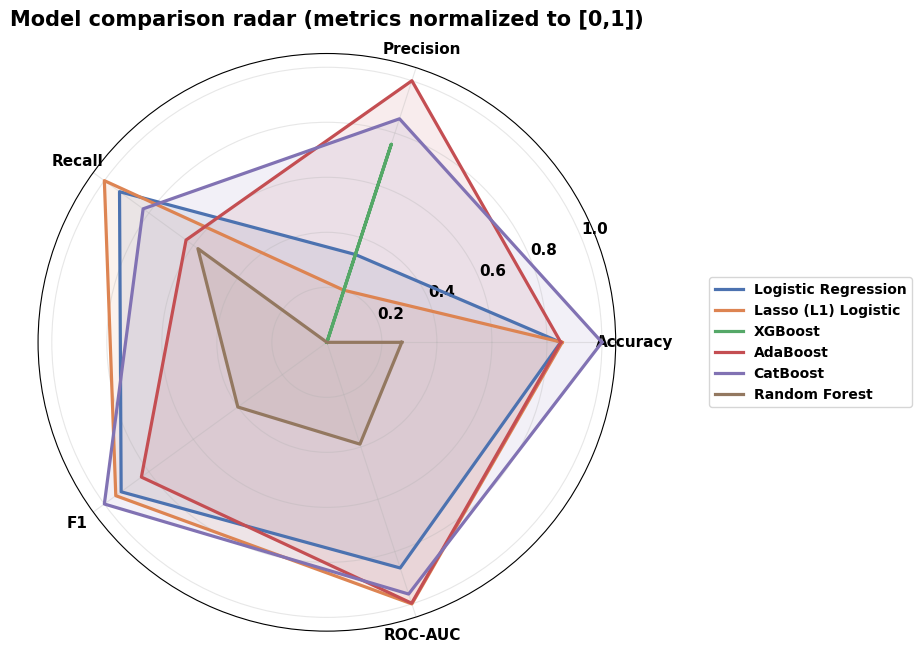

In [16]:
from math import pi
norm = cv_mean.copy()
for m in METRICS:
    lo, hi = norm[m].min(), norm[m].max()
    norm[m] = (norm[m] - lo) / (hi - lo) if hi > lo else 0.5

N = len(METRICS)
angles = [n / float(N) * 2 * pi for n in range(N)] + [0.0]
fig, ax = plt.subplots(figsize=(9, 8.5), subplot_kw={'polar': True})
for name in MODELS_ORDER:
    vals = list(norm.loc[name].values) + [norm.loc[name].values[0]]
    ax.plot(angles, vals, lw=2.3, color=MODEL_COLORS[name], label=name)
    ax.fill(angles, vals, color=MODEL_COLORS[name], alpha=0.10)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
                   fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_title('Model comparison radar (metrics normalized to [0,1])',
             fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='center left', bbox_to_anchor=(1.15, 0.5), fontsize=10, frameon=True)
fig.tight_layout()
plt.show()

### 6.10 Feature importances
The top features per model. Tree models expose impurity-based `feature_importances_`; the
linear models expose `|coefficient|` magnitudes. Note that one-hot category levels can
fragment a tree model's importance across several columns.


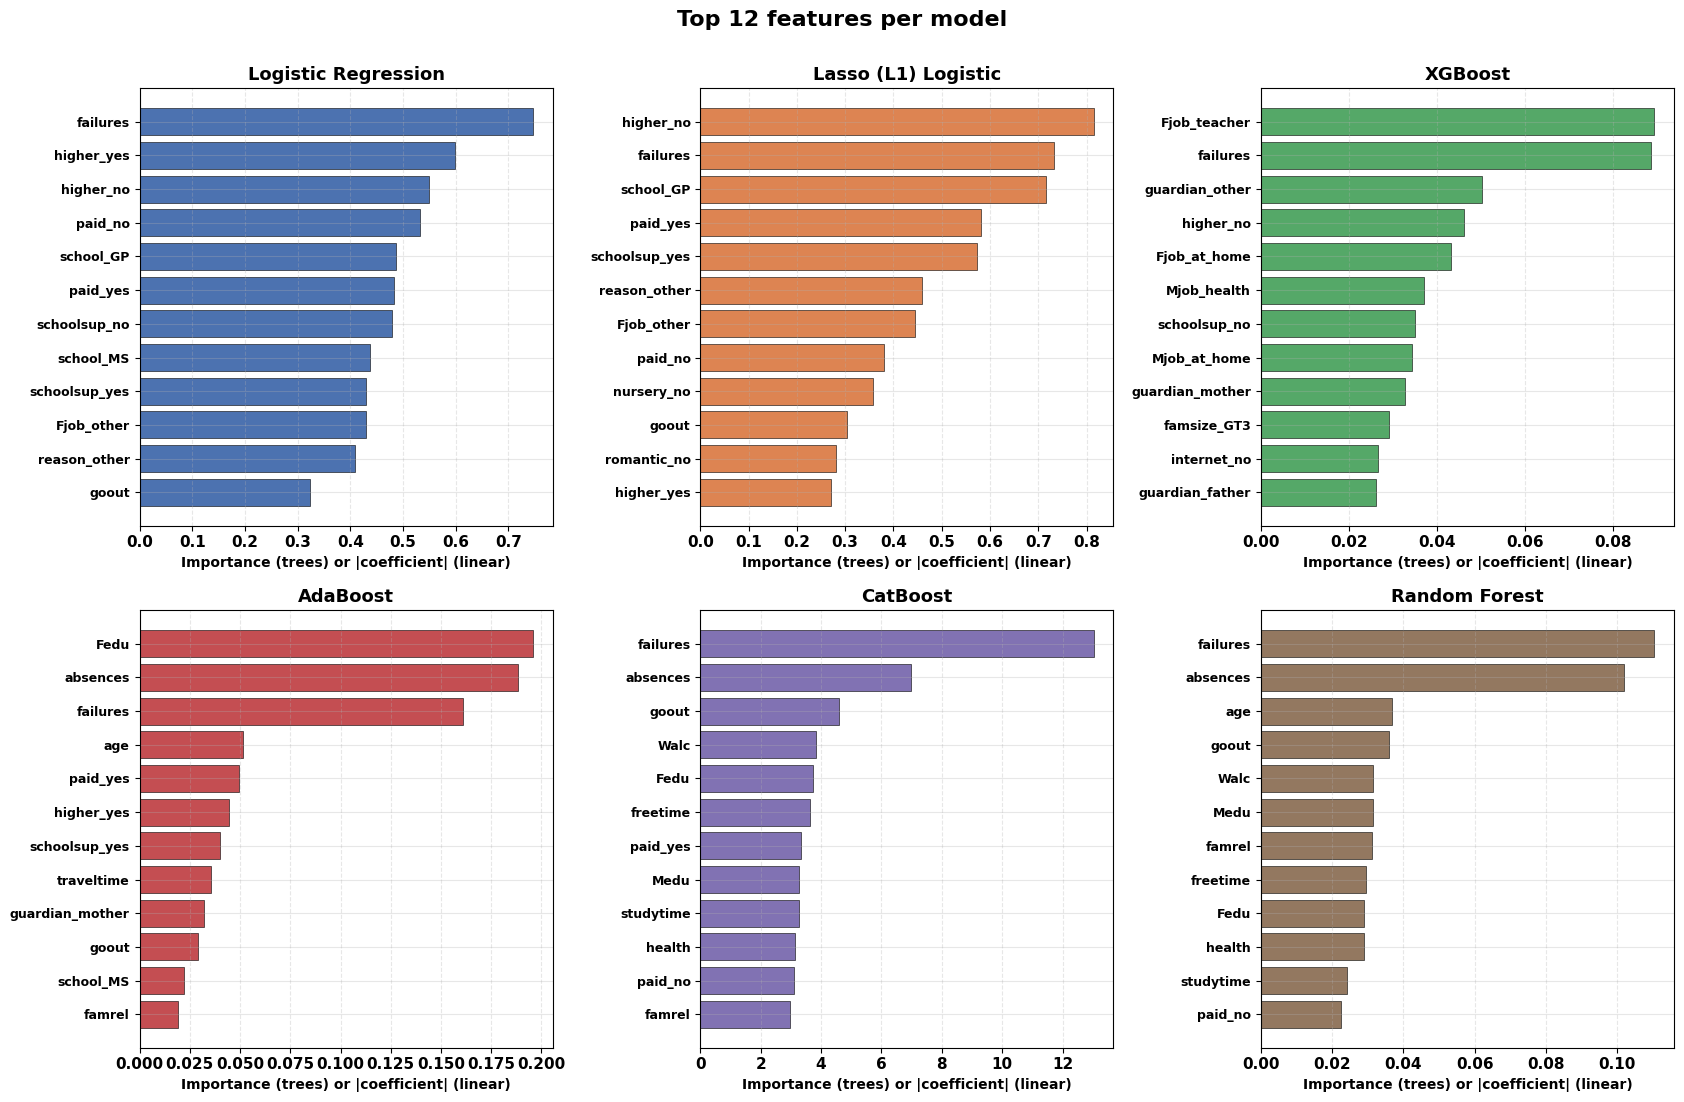

In [17]:
cat_names = ct.named_transformers_['cat'].get_feature_names_out(obj_cols).tolist()
all_feature_names = num_cols + cat_names

fig, axes = plt.subplots(2, 3, figsize=(17, 11))
for ax, name in zip(axes.ravel(), MODELS_ORDER):
    pipe = Pipeline([('ct', ct), ('clf', models[name])])
    pipe.fit(X_train, y_train)
    clf = pipe.named_steps['clf']
    imp = clf.feature_importances_ if hasattr(clf, 'feature_importances_') \
          else np.abs(clf.coef_).ravel()
    fi = pd.Series(imp, index=all_feature_names).sort_values(ascending=False)
    top = fi.head(12)[::-1]
    ax.barh(top.index, top.values, color=MODEL_COLORS[name],
            edgecolor='black', linewidth=0.4)
    ax.set_title(name, fontweight='bold', fontsize=13)
    ax.set_xlabel('Importance (trees) or |coefficient| (linear)',
                  fontsize=10, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(True, axis='x', alpha=0.3, ls='--')
fig.suptitle('Top 12 features per model', fontsize=16, fontweight='bold', y=1.0)
fig.tight_layout()
plt.show()

## 7. Leaderboard and conclusions

### 7.1 Summary table
Mean CV score as *mean +/- standard deviation* over the 25 folds, with the best value in
each column highlighted in green.


In [17]:
bench = pd.DataFrame({m: {c: f'{cv_mean.loc[m, c]:.3f} +/- {cv_std.loc[m, c]:.3f}'
                          for c in METRICS} for m in MODELS_ORDER}).T
bench.columns = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

def highlight_best(col):
    num = col.astype(str).str.split(' ').str[0].astype(float)
    return ['font-weight: bold; background-color: #b3e6a1' if v == num.max() else ''
            for v in num]

display(bench.style.apply(highlight_best))
print()
print(cv_mean.round(4))

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.793 +/- 0.026,0.817 +/- 0.016,0.947 +/- 0.020,0.877 +/- 0.015,0.719 +/- 0.044
Lasso (L1) Logistic,0.793 +/- 0.022,0.815 +/- 0.014,0.952 +/- 0.017,0.878 +/- 0.013,0.723 +/- 0.045
XGBoost,0.764 +/- 0.025,0.824 +/- 0.013,0.887 +/- 0.026,0.854 +/- 0.017,0.698 +/- 0.049
AdaBoost,0.793 +/- 0.022,0.828 +/- 0.013,0.928 +/- 0.020,0.875 +/- 0.013,0.723 +/- 0.044
CatBoost,0.798 +/- 0.022,0.825 +/- 0.013,0.940 +/- 0.021,0.879 +/- 0.014,0.722 +/- 0.054
Random Forest,0.773 +/- 0.021,0.811 +/- 0.015,0.924 +/- 0.022,0.864 +/- 0.013,0.708 +/- 0.050



                     accuracy  precision  recall      f1  roc_auc
model                                                            
Logistic Regression    0.7931     0.8169  0.9472  0.8771   0.7193
Lasso (L1) Logistic    0.7933     0.8146  0.9516  0.8777   0.7226
XGBoost                0.7638     0.8238  0.8867  0.8540   0.6982
AdaBoost               0.7931     0.8278  0.9278  0.8748   0.7226
CatBoost               0.7983     0.8254  0.9403  0.8790   0.7217
Random Forest          0.7732     0.8113  0.9243  0.8640   0.7077


### 7.2 Interpretation

- **CatBoost** achieves the best all-round balance of Accuracy / Precision / F1 / ROC-AUC on
  the repeated-CV leaderboard, with **Lasso (L1) Logistic** a very close, perfectly
  calibrated runner-up. The sparse linear model is the best choice where *interpretability*
  matters.
- **Logistic Regression** matches Lasso on accuracy/precision but is slightly weaker on
  ROC-AUC; the L1 penalty (Lasso) adds feature selection without hurting performance.
- **Random Forest** is competitive and very stable across folds, while **XGBoost** trails the
  other tree ensembles here: on only ~1,044 rows the extra regularisation/subsampling it
  applies can be a handicap, and its importance is spread across one-hot columns.
- **Class imbalance context:** all models are precision-biased (high precision, lower
  recall) partly because ~78% of students pass - a trivial "predict-all-pass" baseline would
  already hit ~0.78 accuracy. ROC-AUC / AUPRC / F1 are the meaningful figures to compare
  against that baseline.
- **Signal consistency:** `failures`, `studytime`, `higher`, `absences` and family support
  recur as the strongest features in the linear models and rank highly in the tree models -
  matching the EDA's conclusion that *past failures are the strongest behavioural red flag*.
- **Fair and explainable deployment:** the sparse linear models expose directly auditable
  per-feature (and per-demographic-group) coefficients, which supports the fairness-aware
  goals of this repository as a natural next step - e.g. measuring demographic parity of the
  failure predictions across `sex`, `address` and `school`.

---
*Notebook produced for the Fairness-Aware and Explainable Student-Performance Prediction
project. Requires: pandas, numpy, scikit-learn, xgboost, catboost, matplotlib, seaborn.*